Processed data is stored in pkl file<br>
Load data and fit with PyMC<br>
Pt100 KOH CO oxidation<br>

In [1]:
from setup import *

In [2]:
# Collision theory 
m_CO = 28.01e-3 / N_A # Mass of CO molecule in kg
P_atm_to_Pa = 101325 # 1 atm to Pa
A_site = F * 1e-4 / (210e-6 * N_A) # Surface area of a single Pt site: 1cm2 = 210uC (HUPD)
sticking_coeff = 0.8
k1_collision = sticking_coeff * A_site * P_atm_to_Pa / np.sqrt(2*np.pi*m_CO*kb_J*T)
log_k1_collision = np.log(k1_collision)

# Smoluchowski theory
henry_constant = 9.3e-4 * 1000 # mol/m^3/atm for CO in water at 293.15K 
diffusion_coefficient = 1.91e-9 # m2/s for CO in water at 293.15K 
k1_smol = 2 * np.pi * diffusion_coefficient * (3e-10) * henry_constant * N_A # 3e-10 m is the effective radius of the Pt site
log_k1_smol = np.log(k1_smol)

# 1D Fickian diffusion 
henry_constant = 9.3e-4 * 1000 # mol/m^3/atm for CO in water at 293.15K 
diffusion_coefficient = 1.91e-9 # m2/s for CO in water at 293.15K 
A_site = F * 1e-4 / (210e-6 * N_A) # Surface area of a single Pt site: 1cm2 = 210uC (HUPD)
delta_BL = 10e-6 # m for a flag in a stirred beaker
k1_fick = diffusion_coefficient * henry_constant * N_A * A_site / delta_BL
log_k1_fick = np.log(k1_fick)

# ER 1 2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.63,11
,3000,0,0.67,7
,3000,0,0.70,7
,3000,0,0.63,7


Computed from 4000 posterior samples and 581 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  1339.38    36.84
p_loo        5.76        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      581  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



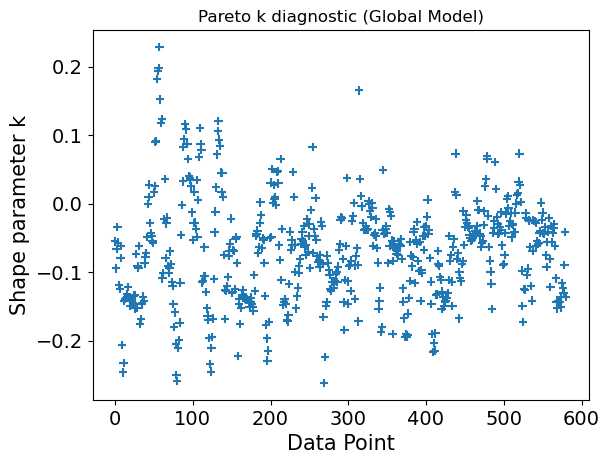

In [5]:
with pm.Model() as ER_1_2: # Winner winner chicken dinner 
    '''
    1. CO + * <-> CO* (Fick) (Irr)
    2. CO* + OH- -> COOH* + (e-) (SSA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    # deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.1) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    Gact2_0 = pm.Normal('Gact2_0', mu=0.75, sigma=0.1) # at 0V_SHE

    # Thermodynamics 
    # deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    # log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k1 = log_k1_fick
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    # term_CO = log_k1 + np.log(P_CO_in) - pt.logaddexp(log_k1 - log_K1, log_k2 + np.log(C_KOH_in))
    term_CO = log_k1 + np.log(P_CO_in) - (log_k2 + np.log(C_KOH_in))
    term_OH = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))

    # Rate expression
    log_rate_model = log_k2 + np.log(C_KOH_in) + log_theta_CO 
    log_rate = observables(log_rate_model) 

trace_ER_1_2, loo_ER_1_2 = fit_and_evaluate(ER_1_2, target_accept=0.9)

            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG4_0  0.090  0.005   0.081    0.101        0.0      0.0    3034.0    2461.0    1.0
Gact2_0    0.744  0.001   0.742    0.745        0.0      0.0    2342.0    2151.0    1.0
beta_2     0.283  0.006   0.272    0.296        0.0      0.0    2424.0    2533.0    1.0
sigma      0.340  0.013   0.315    0.365        0.0      0.0    3577.0    3184.0    1.0


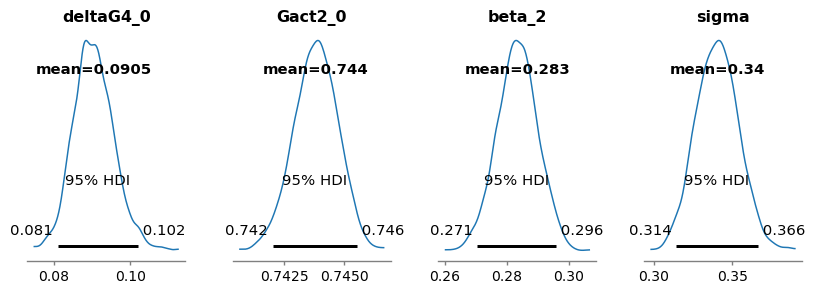

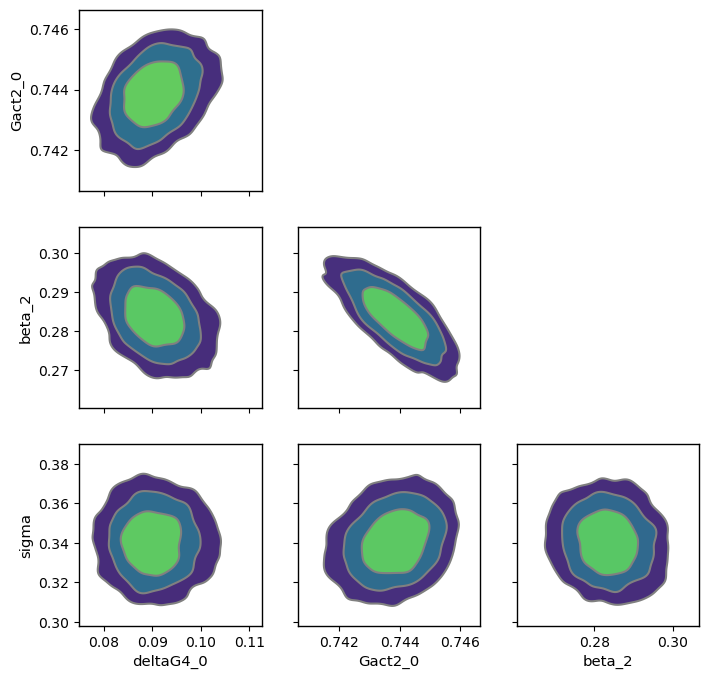

Sampling: [rate]


rate: 0.772


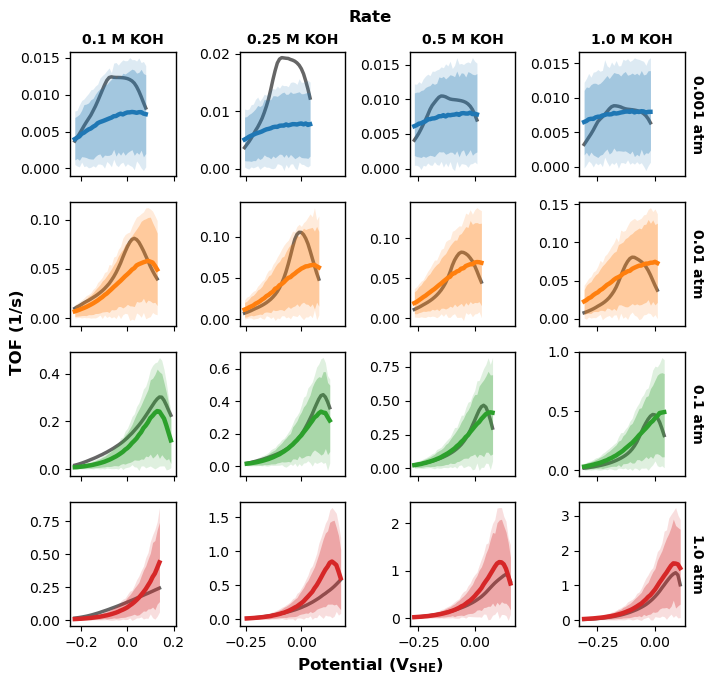

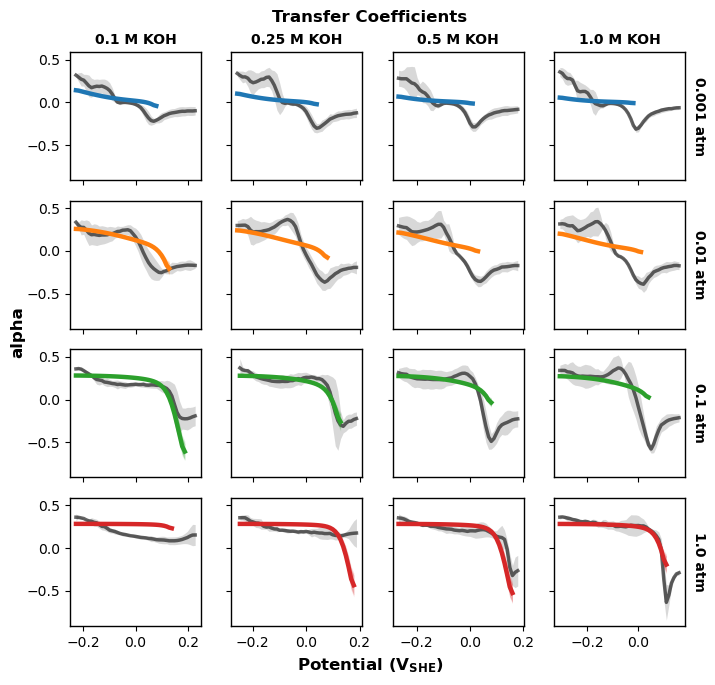

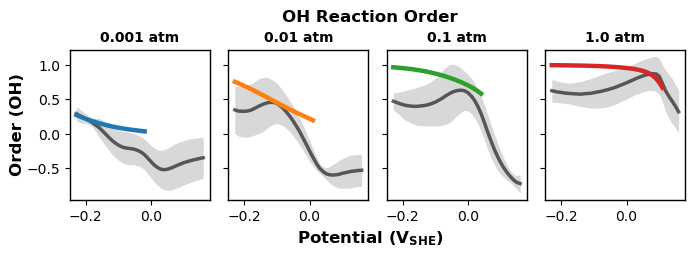

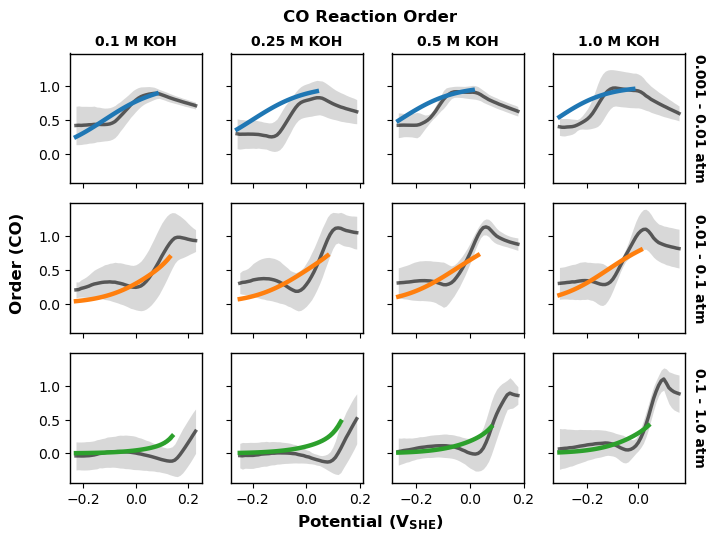

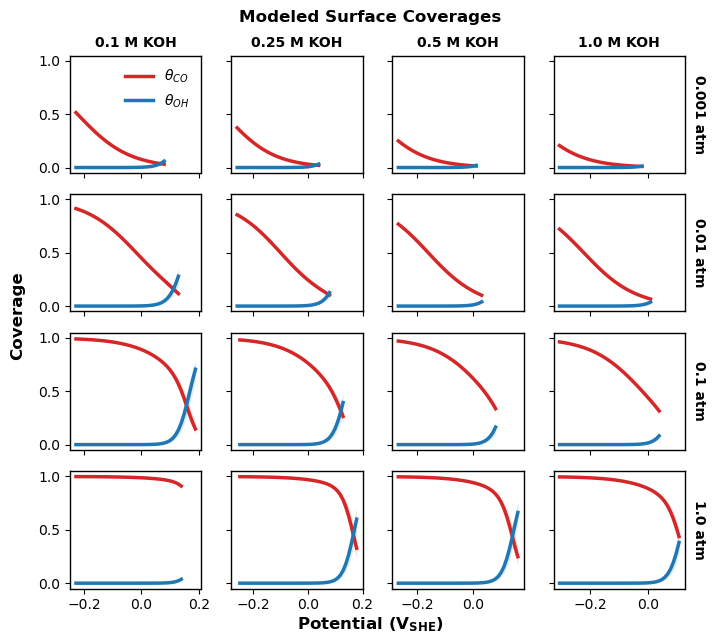

In [6]:
ppc_ER_1_2 = plot_posteriors(trace_ER_1_2, ER_1_2, plot_target)
plot_model_fits(trace_ER_1_2, ppc_ER_1_2); plot_coverages(trace_ER_1_2)

# ER LH 1 2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.61,7
,3000,0,0.60,7
,3000,0,0.63,3
,3000,0,0.59,7


Computed from 4000 posterior samples and 581 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  1339.52    36.82
p_loo        5.73        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      581  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



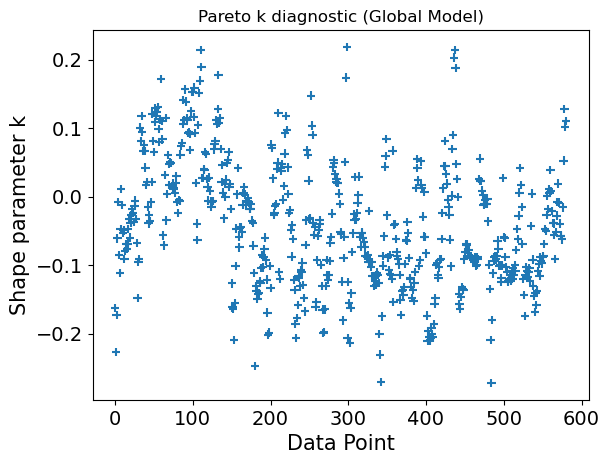

In [7]:
with pm.Model() as ER_LH_1_2: # LH is dead in the water
    '''
    1. CO + * <-> CO* (Fick) (Irr)
    2a. CO* + OH- -> COOH* + (e-) (SSA)
    2b. CO* + OH* -> COOH* + * (SSA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    # deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.1) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    Gact2_ER_0 = pm.TruncatedNormal('Gact2_ER_0', mu=0.75, sigma=0.1, lower=0.7) # at 0V_SHE
    Gact2_LH_0 = pm.TruncatedNormal('Gact2_LH_0', mu=0.75, sigma=0.1, lower=0.7)

    # Thermodynamics 
    # deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2_ER = Gact2_ER_0 - beta_2*E_in
    Gact2_LH = Gact2_LH_0
    # log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k1 = log_k1_fick
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)

    term_OH = log_K4 + np.log(C_KOH_in)
    gamma_OH_lin = pt.exp(term_OH)
    k1_fwd_lin = pt.exp(log_k1 + np.log(P_CO_in))
    k2_ER_lin = pt.exp(log_k2_ER + np.log(C_KOH_in))
    k2_LH_lin = pt.exp(log_k2_LH + term_OH)
    site_block = 1.0 + gamma_OH_lin
    a_term = k2_ER_lin
    b_term = k2_ER_lin * site_block + k2_LH_lin - k1_fwd_lin
    c_term = - k1_fwd_lin * site_block
    gamma_CO_lin = (-b_term + pt.sqrt(b_term**2 - 4 * a_term * c_term)) / (2 * a_term)
    term_CO = pt.log(gamma_CO_lin)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta
    
    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))

    # Rate expression
    rate_ER = log_k2_ER + np.log(C_KOH_in) + log_theta_CO
    rate_LH = log_k2_LH + log_theta_CO + log_theta_OH
    log_rate_model = pt.logaddexp(rate_ER, rate_LH)
    log_rate = observables(log_rate_model) 

trace_ER_LH_1_2, loo_ER_LH_1_2 = fit_and_evaluate(ER_LH_1_2, target_accept=0.9)

             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG4_0   0.089  0.005   0.080    0.099      0.000    0.000    3391.0    2588.0    1.0
beta_2      0.283  0.007   0.270    0.295      0.000    0.000    2067.0    2497.0    1.0
Gact2_ER_0  0.744  0.001   0.742    0.746      0.000    0.000    2096.0    2419.0    1.0
Gact2_LH_0  0.821  0.061   0.734    0.936      0.001    0.001    2890.0    3098.0    1.0
sigma       0.340  0.014   0.315    0.365      0.000    0.000    4313.0    2918.0    1.0


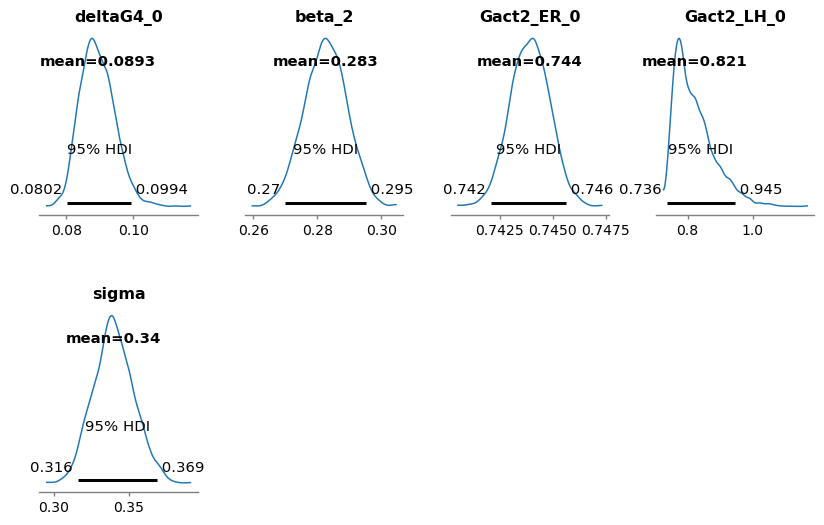

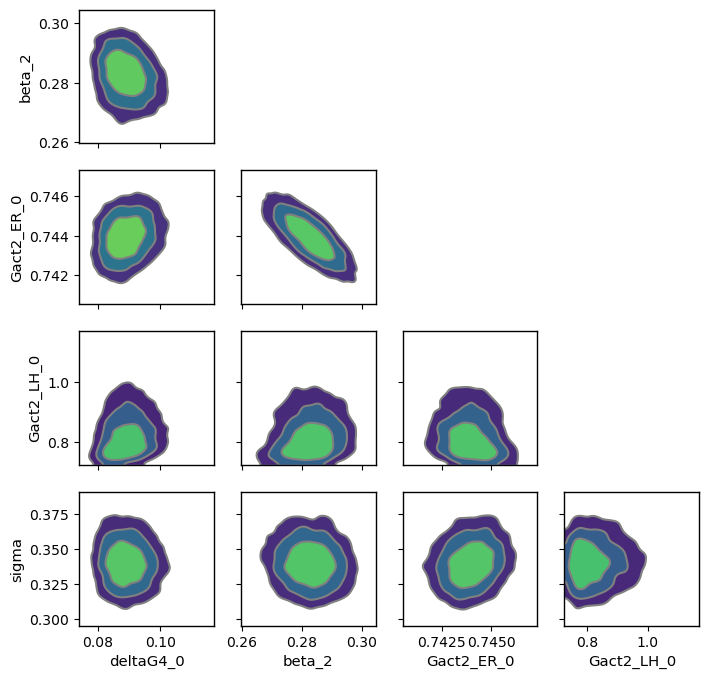

Sampling: [rate]


rate: 0.772


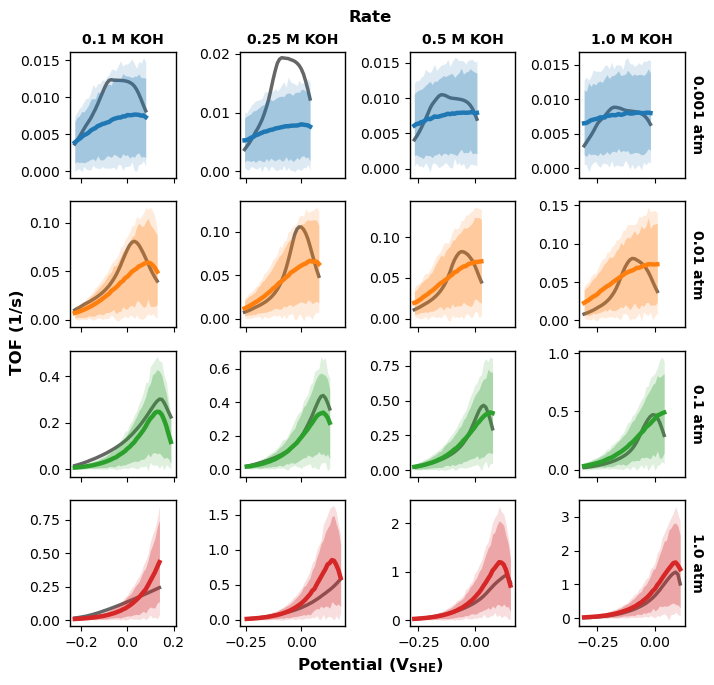

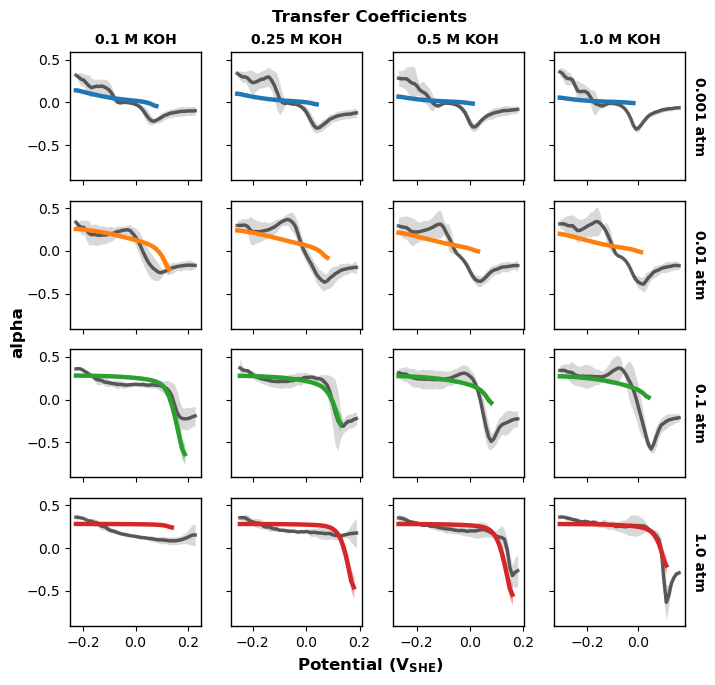

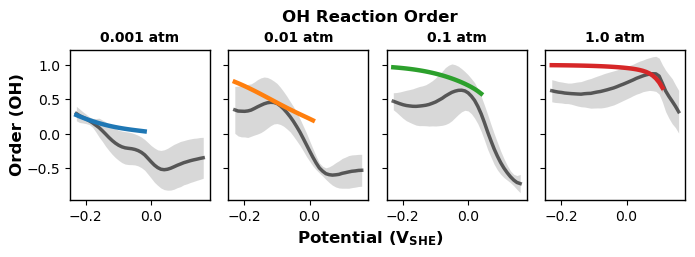

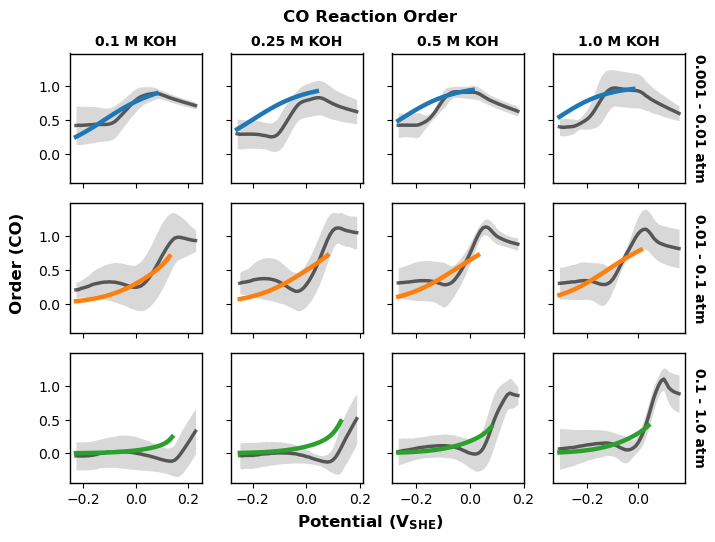

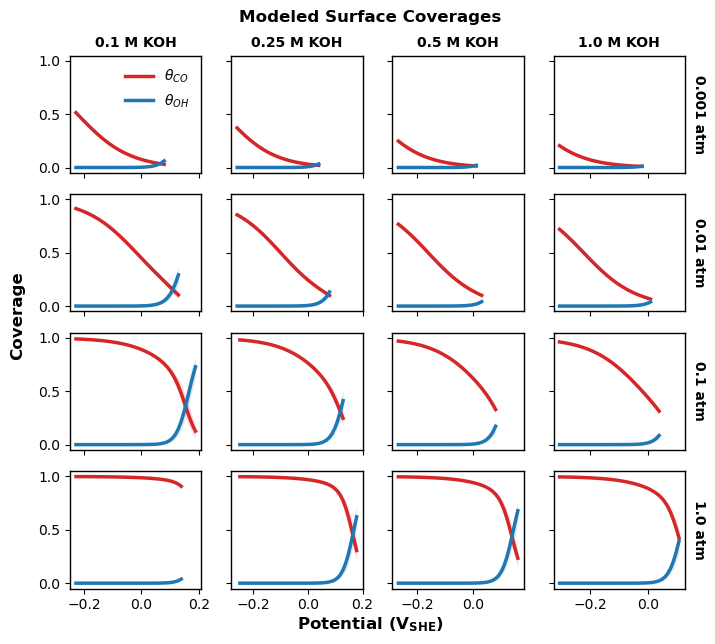

In [8]:
ppc_ER_LH_1_2 = plot_posteriors(trace_ER_LH_1_2, ER_LH_1_2, plot_target)
plot_model_fits(trace_ER_LH_1_2, ppc_ER_LH_1_2); plot_coverages(trace_ER_LH_1_2)

# ER 1 2 3

In [ ]:
with pm.Model() as ER_1_2_3: # Overfitting? 
    '''
    1. CO + * <-> CO* (Fick) (Irr)
    2. CO* + OH- <-> COOH* + (e-) (SSA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (SSA) (Irr)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    # deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.1) # at 0V_SHE
    deltaG2_0 = pm.Normal('deltaG2_0', mu=-0.1, sigma=0.1) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    beta_3 = pm.Uniform('beta_3', lower=0.25, upper=1)
    Gact2_0 = pm.TruncatedNormal('Gact2_0', mu=0.75, sigma=0.1, lower=0.7) # at 0V_SHE
    Gact3_0 = pm.TruncatedNormal('Gact3_0', mu=0.55, sigma=0.1, lower=0) # at 0V_SHE

    # Thermodynamics 
    # deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG2 = deltaG2_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    Gact3 = Gact3_0 - beta_3*E_in
    # log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K2 = -deltaG2/(kb_eV*T)
    log_k1 = log_k1_fick
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)
    log_k3 = np.log(kb_J*T/h) - Gact3/(kb_eV*T)

    log_denom_COOH = pt.logaddexp(log_k2 - log_K2, log_k3 + np.log(C_KOH_in))
    log_k2_k3_term = log_k2 + log_k3 + 2*np.log(C_KOH_in) - log_denom_COOH
    term_CO = log_k1 + np.log(P_CO_in) - log_k2_k3_term
    term_OH = log_K4 + np.log(C_KOH_in)
    term_COOH = log_k2 + np.log(C_KOH_in) - log_denom_COOH + term_CO
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH, term_COOH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta
    log_theta_COOH = term_COOH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_COOH = pm.Deterministic('theta_COOH', pt.exp(log_theta_COOH))

    # Rate expression
    log_rate_model = log_k3 + np.log(C_KOH_in) + log_theta_COOH
    log_rate = observables(log_rate_model) 

trace_ER_1_2_3, loo_ER_1_2_3 = fit_and_evaluate(ER_1_2_3, target_accept=0.99)

In [ ]:
ppc_ER_1_2_3 = plot_posteriors(trace_ER_1_2_3, ER_1_2_3, plot_target)
plot_model_fits(trace_ER_1_2_3, ppc_ER_1_2_3); plot_coverages(trace_ER_1_2_3)

# ER 1 2 Kinetics

In [ ]:
with pm.Model() as ER_1_2_kin: # Shows that CO adsorption is only limited by MT, desorption is slow, adsorption is kinetically fast
    '''
    1. CO + * <-> CO* (Mass Transfer + Kinetic Adsorption/Desorption)
    2. CO* + OH- -> COOH* + (e-) (SSA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    Gact1_0 = pm.TruncatedNormal('Gact1_0', mu=0.7, sigma=0.1, lower=0) # Kinetic barrier for adsorption
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.1) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    Gact2_0 = pm.TruncatedNormal('Gact2_0', mu=0.75, sigma=0.1, lower=0.7) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k1_fick_term = log_k1_fick 
    log_k1_kin = np.log(kb_J*T/h) - Gact1_0/(kb_eV*T)
    log_k1_eff = -pt.logaddexp(-log_k1_fick_term, -log_k1_kin) 
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    log_denom_CO = pt.logaddexp(log_k1_kin - log_K1, log_k2 + np.log(C_KOH_in))
    term_CO = log_k1_eff + np.log(P_CO_in) - log_denom_CO
    term_OH = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))

    # Rate expression
    log_rate_model = log_k2 + np.log(C_KOH_in) + log_theta_CO 
    log_rate = observables(log_rate_model) 

trace_ER_1_2_kin, loo_ER_1_2_kin = fit_and_evaluate(ER_1_2_kin, target_accept=0.99)

In [ ]:
ppc_ER_1_2_kin = plot_posteriors(trace_ER_1_2_kin, ER_1_2_kin, plot_target)
plot_model_fits(trace_ER_1_2_kin, ppc_ER_1_2_kin); plot_coverages(trace_ER_1_2_kin)

# ER 1 2 Lateral

# Comparison

In [ ]:
comparison_dict = {
    'ER_1_2': loo_ER_1_2,
    'ER_LH_1_2': loo_ER_LH_1_2,
    'ER_1_2_3': loo_ER_1_2_3, 
    'ER_1_2_kin': loo_ER_1_2_kin, 
    # 'ER_1_2_lateral': loo_ER_1_2_lateral,
}

comp_df = az.compare(comparison_dict, ic="loo", method="stacking")
print(comp_df)
az.plot_compare(comp_df, insample_dev=False)
plt.show()